# DataCo Supply Chain Analysis

## Strategic Logistics Planning and Late Delivery Risk Analysis

**Objective:**  
To analyze supply-chain operations, identify factors contributing to late deliveries,
measure logistics performance using KPIs, and develop predictive and analytical
solutions using Python.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans


In [3]:
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


In [4]:
df = pd.read_csv(r"C:\Users\arkat\OneDrive\Desktop\M.tech\b.techprojects\Internship projects\Logistics Data Analyst Intern\TASK-1\DataCoSupplyChainDataset_Cleaned.csv")

print("Dataset loaded successfully")

Dataset loaded successfully


In [5]:
df = pd.read_csv(r"C:\Users\arkat\OneDrive\Desktop\M.tech\b.techprojects\Internship projects\Logistics Data Analyst Intern\TASK-1\DataCoSupplyChainDataset_Cleaned.csv")

In [6]:
df.shape

(180519, 52)

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 180519
Number of columns: 52


In [8]:
df.head()

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_Status,Order_Zipcode,Product_Card_Id,Product_Category_Id,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,59405.0,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,59405.0,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,59405.0,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,COMPLETE,59405.0,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,PENDING_PAYMENT,59405.0,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


In [9]:
df.tail()

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_Status,Order_Zipcode,Product_Card_Id,Product_Category_Id,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,CLOSED,59405.0,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 03:40:00,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,COMPLETE,59405.0,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-19 01:34:00,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,PENDING,59405.0,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 21:00:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,PENDING_PAYMENT,59405.0,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-18 20:18:00,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,...,PENDING_PAYMENT,59405.0,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-19 18:54:00,Standard Class


In [10]:
df.sample(5)

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_Status,Order_Zipcode,Product_Card_Id,Product_Category_Id,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
105122,PAYMENT,2,1,16.590000,82.970001,Late delivery,1,46,Indoor/Outdoor Games,San Diego,...,PAYMENT_REVIEW,59405.0,1014,46,http://images.acmesports.sports/O%27Brien+Men%...,O'Brien Men's Neoprene Life Vest,49.980000,0,2017-06-22 22:44:00,First Class
32062,PAYMENT,3,4,17.920000,37.330002,Advance shipping,0,36,Golf Balls,Brooklyn,...,PENDING_PAYMENT,59405.0,792,36,http://images.acmesports.sports/Hirzl+Men%27s+...,Hirzl Men's Hybrid Golf Glove,14.990000,0,2015-10-05 23:05:00,Standard Class
19022,PAYMENT,2,1,51.790001,107.889999,Late delivery,1,18,Men's Footwear,Philadelphia,...,PENDING_PAYMENT,46203.0,403,18,http://images.acmesports.sports/Nike+Men%27s+C...,Nike Men's CJ Elite 2 TD Football Cleat,129.990005,0,2016-06-05 08:54:00,First Class
22072,DEBIT,5,4,5.370000,76.779999,Late delivery,1,29,Shop By Sport,Caguas,...,COMPLETE,59405.0,627,29,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,2017-09-19 13:51:00,Standard Class
34354,CASH,2,4,-154.350006,99.580002,Advance shipping,0,17,Cleats,Martinsburg,...,CLOSED,59405.0,365,17,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,2016-10-28 13:26:00,Standard Class


In [11]:
df.columns.tolist()

['Type',
 'Days_for_shipping_(real)',
 'Days_for_shipment_(scheduled)',
 'Benefit_per_order',
 'Sales_per_customer',
 'Delivery_Status',
 'Late_delivery_risk',
 'Category_Id',
 'Category_Name',
 'Customer_City',
 'Customer_Country',
 'Customer_Email',
 'Customer_Fname',
 'Customer_Id',
 'Customer_Lname',
 'Customer_Password',
 'Customer_Segment',
 'Customer_State',
 'Customer_Street',
 'Customer_Zipcode',
 'Department_Id',
 'Department_Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order_City',
 'Order_Country',
 'Order_Customer_Id',
 'order_date_(DateOrders)',
 'Order_Id',
 'Order_Item_Cardprod_Id',
 'Order_Item_Discount',
 'Order_Item_Discount_Rate',
 'Order_Item_Id',
 'Order_Item_Product_Price',
 'Order_Item_Profit_Ratio',
 'Order_Item_Quantity',
 'Sales',
 'Order_Item_Total',
 'Order_Profit_Per_Order',
 'Order_Region',
 'Order_State',
 'Order_Status',
 'Order_Zipcode',
 'Product_Card_Id',
 'Product_Category_Id',
 'Product_Image',
 'Product_Name',
 'Product_Price',
 'Product_Status'

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 52 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days_for_shipping_(real)       180519 non-null  int64  
 2   Days_for_shipment_(scheduled)  180519 non-null  int64  
 3   Benefit_per_order              180519 non-null  float64
 4   Sales_per_customer             180519 non-null  float64
 5   Delivery_Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category_Id                    180519 non-null  int64  
 8   Category_Name                  180519 non-null  object 
 9   Customer_City                  180519 non-null  object 
 10  Customer_Country               180519 non-null  object 
 11  Customer_Email                 180519 non-null  object 
 12  Customer_Fname                

In [13]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [14]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [15]:
print("Duplicate records:", df.duplicated().sum())

Duplicate records: 0


In [16]:
df.dtypes

Type                              object
Days_for_shipping_(real)           int64
Days_for_shipment_(scheduled)      int64
Benefit_per_order                float64
Sales_per_customer               float64
Delivery_Status                   object
Late_delivery_risk                 int64
Category_Id                        int64
Category_Name                     object
Customer_City                     object
Customer_Country                  object
Customer_Email                    object
Customer_Fname                    object
Customer_Id                        int64
Customer_Lname                    object
Customer_Password                 object
Customer_Segment                  object
Customer_State                    object
Customer_Street                   object
Customer_Zipcode                 float64
Department_Id                      int64
Department_Name                   object
Latitude                         float64
Longitude                        float64
Market          

In [17]:
numeric_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns

print("Numerical columns:")
print(numeric_columns.tolist())

print("\nCategorical columns:")
print(categorical_columns.tolist())

Numerical columns:
['Days_for_shipping_(real)', 'Days_for_shipment_(scheduled)', 'Benefit_per_order', 'Sales_per_customer', 'Late_delivery_risk', 'Category_Id', 'Customer_Id', 'Customer_Zipcode', 'Department_Id', 'Latitude', 'Longitude', 'Order_Customer_Id', 'Order_Id', 'Order_Item_Cardprod_Id', 'Order_Item_Discount', 'Order_Item_Discount_Rate', 'Order_Item_Id', 'Order_Item_Product_Price', 'Order_Item_Profit_Ratio', 'Order_Item_Quantity', 'Sales', 'Order_Item_Total', 'Order_Profit_Per_Order', 'Order_Zipcode', 'Product_Card_Id', 'Product_Category_Id', 'Product_Price', 'Product_Status']

Categorical columns:
['Type', 'Delivery_Status', 'Category_Name', 'Customer_City', 'Customer_Country', 'Customer_Email', 'Customer_Fname', 'Customer_Lname', 'Customer_Password', 'Customer_Segment', 'Customer_State', 'Customer_Street', 'Department_Name', 'Market', 'Order_City', 'Order_Country', 'order_date_(DateOrders)', 'Order_Region', 'Order_State', 'Order_Status', 'Product_Image', 'Product_Name', 'ship

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days_for_shipping_(real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days_for_shipment_(scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit_per_order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales_per_customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category_Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer_Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer_Zipcode,180519.0,35920.852021,37542.209723,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department_Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [19]:
# Display all column names
for i, col in enumerate(df.columns, start=1):
    print(i, ":", col)

1 : Type
2 : Days_for_shipping_(real)
3 : Days_for_shipment_(scheduled)
4 : Benefit_per_order
5 : Sales_per_customer
6 : Delivery_Status
7 : Late_delivery_risk
8 : Category_Id
9 : Category_Name
10 : Customer_City
11 : Customer_Country
12 : Customer_Email
13 : Customer_Fname
14 : Customer_Id
15 : Customer_Lname
16 : Customer_Password
17 : Customer_Segment
18 : Customer_State
19 : Customer_Street
20 : Customer_Zipcode
21 : Department_Id
22 : Department_Name
23 : Latitude
24 : Longitude
25 : Market
26 : Order_City
27 : Order_Country
28 : Order_Customer_Id
29 : order_date_(DateOrders)
30 : Order_Id
31 : Order_Item_Cardprod_Id
32 : Order_Item_Discount
33 : Order_Item_Discount_Rate
34 : Order_Item_Id
35 : Order_Item_Product_Price
36 : Order_Item_Profit_Ratio
37 : Order_Item_Quantity
38 : Sales
39 : Order_Item_Total
40 : Order_Profit_Per_Order
41 : Order_Region
42 : Order_State
43 : Order_Status
44 : Order_Zipcode
45 : Product_Card_Id
46 : Product_Category_Id
47 : Product_Image
48 : Product_N

In [20]:
logistics_columns = [
    "Late_delivery_risk",
    "Days_for_shipping_(real)",
    "Days_for_shipment_(scheduled)",
    "Shipping_Mode",
    "Delivery_Status",
    "Order_Status",
    "Order_Region",
    "Order_Country",
    "Market",
    "Sales",
    "Order_Profit_Per_Order",
    "Order_Item_Quantity",
    "Product_Category_Id"
]

df[logistics_columns].head()

,Late_delivery_risk,Days_for_shipping_(real),Days_for_shipment_(scheduled),Shipping_Mode,Delivery_Status,Order_Status,Order_Region,Order_Country,Market,Sales,Order_Profit_Per_Order,Order_Item_Quantity,Product_Category_Id
0,0,3,4,Standard Class,Advance shipping,COMPLETE,Southeast Asia,Indonesia,Pacific Asia,327.75,91.250000,1,73
1,1,5,4,Standard Class,Late delivery,PENDING,South Asia,India,Pacific Asia,327.75,-249.089996,1,73
2,0,4,4,Standard Class,Shipping on time,CLOSED,South Asia,India,Pacific Asia,327.75,-247.779999,1,73
3,0,3,4,Standard Class,Advance shipping,COMPLETE,Oceania,Australia,Pacific Asia,327.75,22.860001,1,73
4,0,2,4,Standard Class,Advance shipping,PENDING_PAYMENT,Oceania,Australia,Pacific Asia,327.75,134.210007,1,73


In [21]:
logistics_df = df[logistics_columns].copy()

logistics_df.head()

,Late_delivery_risk,Days_for_shipping_(real),Days_for_shipment_(scheduled),Shipping_Mode,Delivery_Status,Order_Status,Order_Region,Order_Country,Market,Sales,Order_Profit_Per_Order,Order_Item_Quantity,Product_Category_Id
0,0,3,4,Standard Class,Advance shipping,COMPLETE,Southeast Asia,Indonesia,Pacific Asia,327.75,91.250000,1,73
1,1,5,4,Standard Class,Late delivery,PENDING,South Asia,India,Pacific Asia,327.75,-249.089996,1,73
2,0,4,4,Standard Class,Shipping on time,CLOSED,South Asia,India,Pacific Asia,327.75,-247.779999,1,73
3,0,3,4,Standard Class,Advance shipping,COMPLETE,Oceania,Australia,Pacific Asia,327.75,22.860001,1,73
4,0,2,4,Standard Class,Advance shipping,PENDING_PAYMENT,Oceania,Australia,Pacific Asia,327.75,134.210007,1,73


In [22]:
logistics_df.shape

(180519, 13)

In [23]:
df["Late_delivery_risk"].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [24]:
df["Late_delivery_risk"].value_counts(normalize=True) * 100

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64

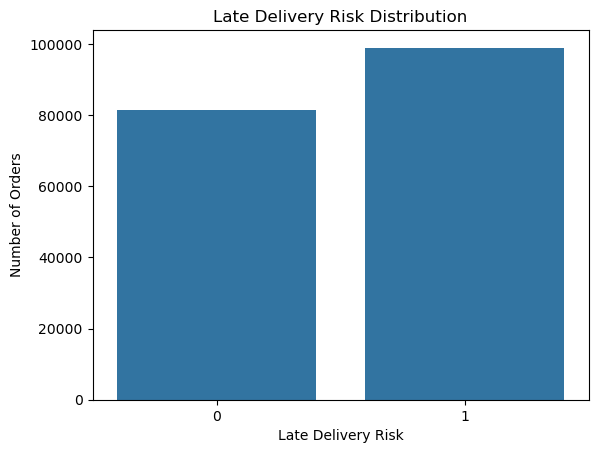

In [25]:
sns.countplot(data=df, x="Late_delivery_risk")

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Orders")

plt.show()

In [26]:
# Create Our First KPI - Late Delivery Rate

late_delivery_rate = (
    df["Late_delivery_risk"].mean() * 100
)

print(f"Late Delivery Rate: {late_delivery_rate:.2f}%")

Late Delivery Rate: 54.83%


In [27]:
on_time_delivery_rate = 100 - late_delivery_rate

print(f"On-Time Delivery Rate: {on_time_delivery_rate:.2f}%")

On-Time Delivery Rate: 45.17%


In [28]:
avg_actual_shipping = df["Days_for_shipping_(real)"].mean()

print(
    f"Average Actual Shipping Time: "
    f"{avg_actual_shipping:.2f} days"
)

Average Actual Shipping Time: 3.50 days


In [29]:
avg_scheduled_shipping = df["Days_for_shipment_(scheduled)"].mean()

print(
    f"Average Scheduled Shipping Time: "
    f"{avg_scheduled_shipping:.2f} days"
)

Average Scheduled Shipping Time: 2.93 days


In [30]:
df["Shipping_Delay"] = (
    df["Days_for_shipping_(real)"]
    - df["Days_for_shipment_(scheduled)"]
)

In [31]:
df["Shipping_Delay"].describe()

count    180519.000000
mean          0.565807
std           1.490966
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: Shipping_Delay, dtype: float64

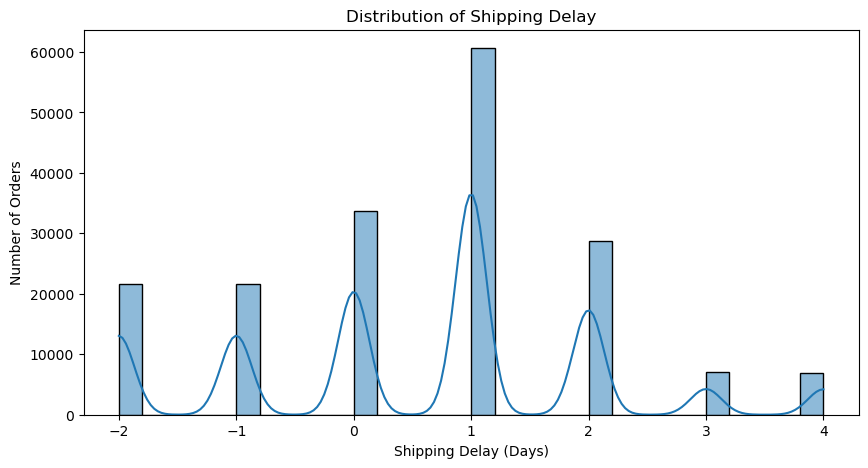

In [32]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["Shipping_Delay"],
    bins=30,
    kde=True
)

plt.title("Distribution of Shipping Delay")
plt.xlabel("Shipping Delay (Days)")
plt.ylabel("Number of Orders")

plt.show()

In [33]:
shipping_mode = (
    df.groupby("Shipping_Mode")
    .agg(
        Orders=("Shipping_Mode", "count"),
        Late_Delivery_Rate=("Late_delivery_risk", "mean")
    )
)

shipping_mode["Late_Delivery_Rate"] *= 100

shipping_mode

,Orders,Late_Delivery_Rate
Shipping_Mode,,
First Class,27814,95.322499
Same Day,9737,45.743042
Second Class,35216,76.632781
Standard Class,107752,38.071683


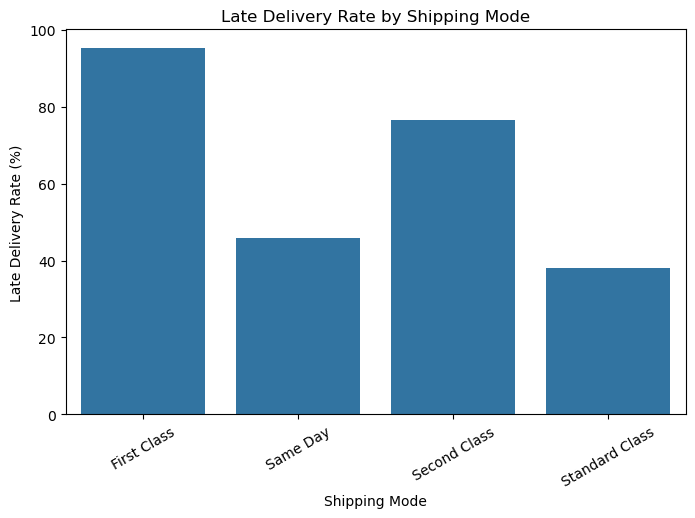

In [34]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=shipping_mode.reset_index(),
    x="Shipping_Mode",
    y="Late_Delivery_Rate"
)

plt.title("Late Delivery Rate by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Late Delivery Rate (%)")

plt.xticks(rotation=30)
plt.show()

In [35]:
# Delivery Status Analysis

delivery_status_counts = df["Delivery_Status"].value_counts()

print(delivery_status_counts)

Delivery_Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64


In [36]:
delivery_status_percentage = (
    df["Delivery_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(delivery_status_percentage)

Delivery_Status
Late delivery        54.83
Advance shipping     23.04
Shipping on time     17.84
Shipping canceled     4.30
Name: proportion, dtype: float64


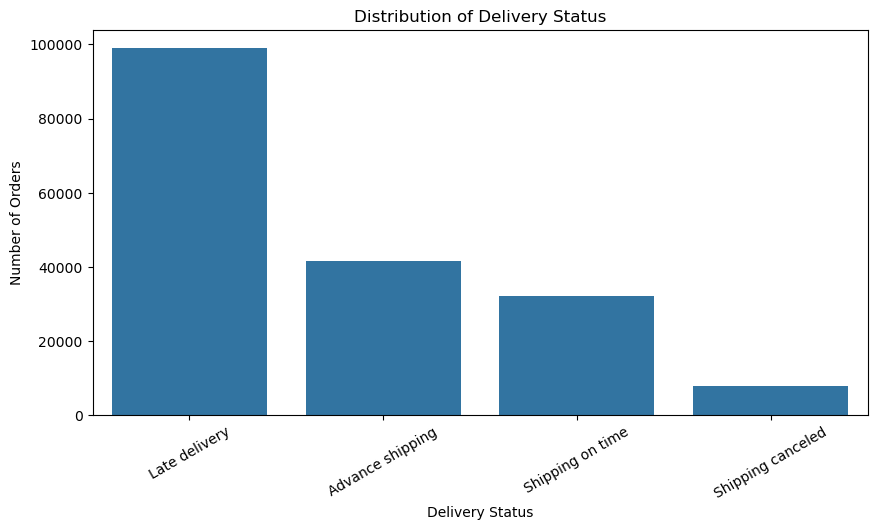

In [37]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Delivery_Status",
    order=df["Delivery_Status"].value_counts().index
)

plt.title("Distribution of Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

plt.show()

In [38]:
# Late Delivery Risk by Delivery Status

delivery_risk_status = pd.crosstab(
    df["Delivery_Status"],
    df["Late_delivery_risk"],
    normalize="index"
) * 100

delivery_risk_status

Late_delivery_risk,0,1
Delivery_Status,,
Advance shipping,100.0,0.0
Late delivery,0.0,100.0
Shipping canceled,100.0,0.0
Shipping on time,100.0,0.0


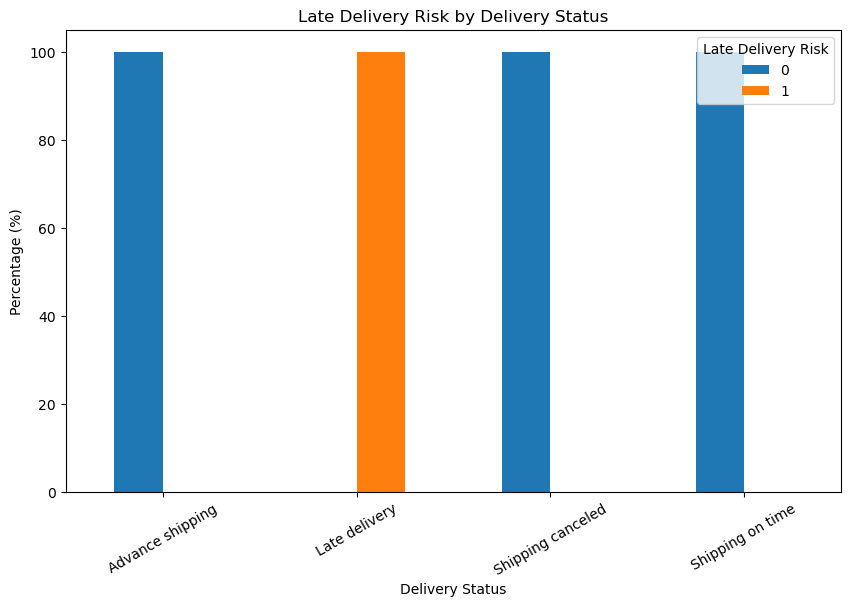

In [39]:
delivery_risk_status.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Late Delivery Risk by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=30)
plt.legend(title="Late Delivery Risk")

plt.show()

In [40]:
# Analyze Shipping Delay

df["Delay_Category"] = np.where(
    df["Shipping_Delay"] > 0,
    "Delayed",
    np.where(
        df["Shipping_Delay"] == 0,
        "On Schedule",
        "Early"
    )
)

In [41]:
df["Delay_Category"].value_counts()

Delay_Category
Delayed        103400
Early           43366
On Schedule     33753
Name: count, dtype: int64

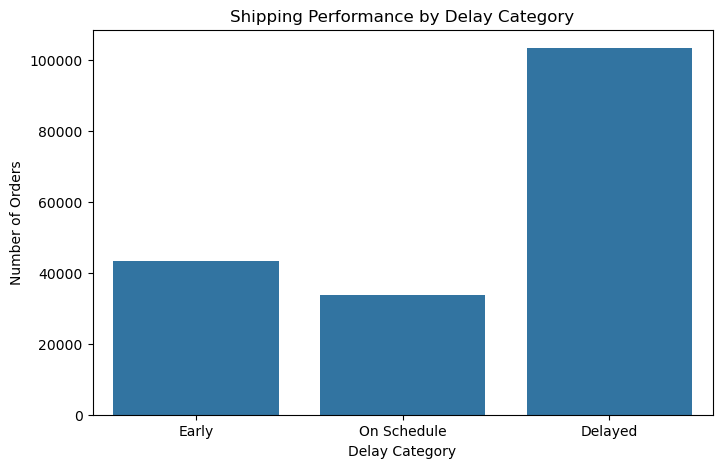

In [42]:
# Delay Category Visualization

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Delay_Category",
    order=["Early", "On Schedule", "Delayed"]
)

plt.title("Shipping Performance by Delay Category")
plt.xlabel("Delay Category")
plt.ylabel("Number of Orders")

plt.show()

In [43]:
# Late Delivery Rate by Market

market_analysis = (
    df.groupby("Market")
    .agg(
        Total_Orders=("Market", "count"),
        Late_Delivery_Rate=("Late_delivery_risk", "mean"),
        Average_Shipping_Delay=("Shipping_Delay", "mean")
    )
)

market_analysis["Late_Delivery_Rate"] *= 100

market_analysis = market_analysis.round(2)

market_analysis

,Total_Orders,Late_Delivery_Rate,Average_Shipping_Delay
Market,,,
Africa,11614,54.59,0.56
Europe,50252,55.21,0.57
LATAM,51594,54.36,0.56
Pacific Asia,41260,55.05,0.57
USCA,25799,54.80,0.57


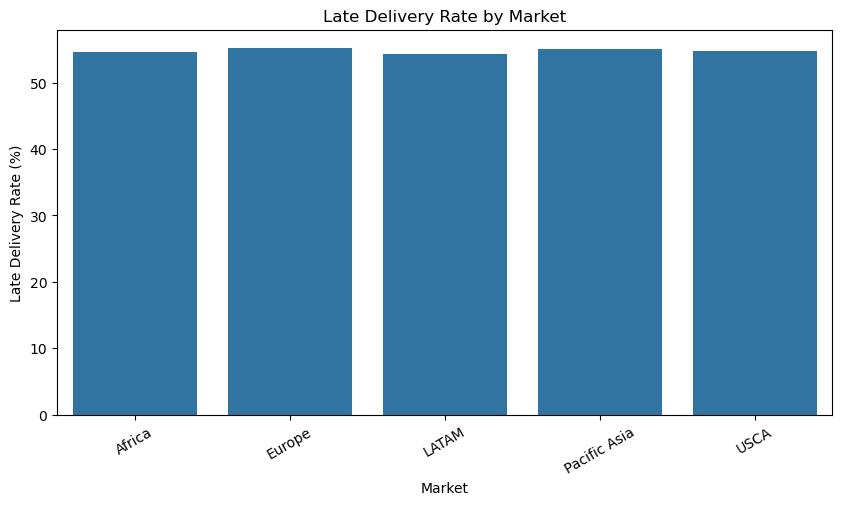

In [44]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=market_analysis.reset_index(),
    x="Market",
    y="Late_Delivery_Rate"
)

plt.title("Late Delivery Rate by Market")
plt.xlabel("Market")
plt.ylabel("Late Delivery Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [45]:
# Late Delivery Rate by Region

region_analysis = (
    df.groupby("Order_Region")
    .agg(
        Total_Orders=("Order_Region", "count"),
        Late_Delivery_Rate=("Late_delivery_risk", "mean"),
        Average_Shipping_Delay=("Shipping_Delay", "mean")
    )
)

region_analysis["Late_Delivery_Rate"] *= 100

region_analysis = region_analysis.sort_values(
    "Late_Delivery_Rate",
    ascending=False
).round(2)

region_analysis

,Total_Orders,Late_Delivery_Rate,Average_Shipping_Delay
Order_Region,,,
Central Africa,1677,57.96,0.64
South Asia,7731,56.27,0.60
East Africa,1852,55.94,0.57
Western Europe,27109,55.85,0.60
South of USA,4045,55.77,0.58
Eastern Europe,3920,55.66,0.58
East of USA,6915,55.66,0.58
Southeast Asia,9539,55.53,0.56
Central Asia,553,55.33,0.65


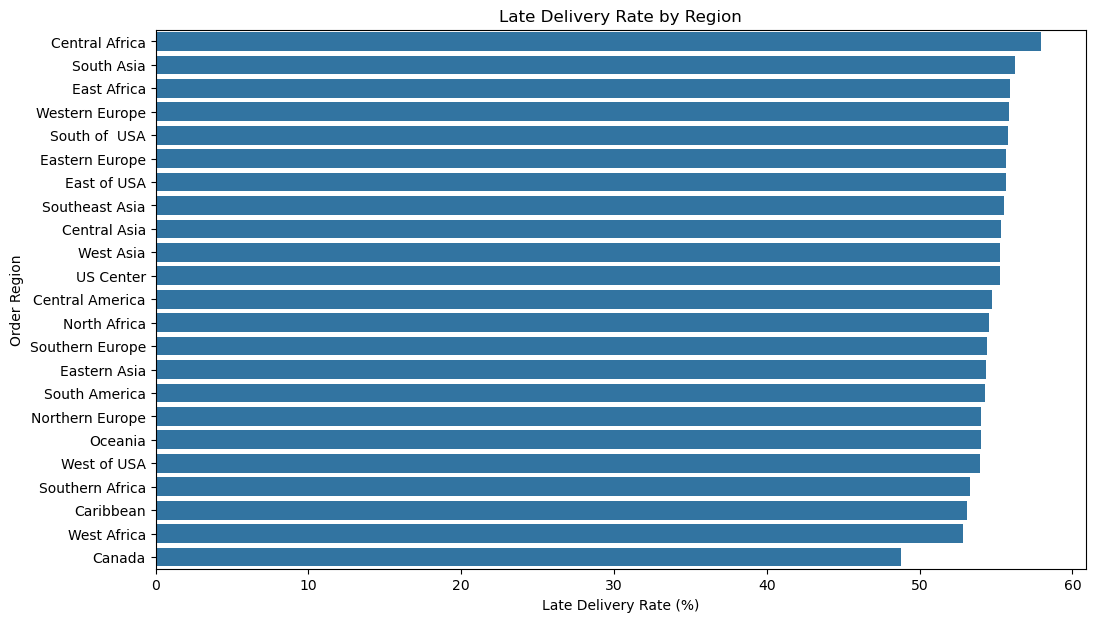

In [46]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=region_analysis.reset_index(),
    x="Late_Delivery_Rate",
    y="Order_Region"
)

plt.title("Late Delivery Rate by Region")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Order Region")

plt.show()

In [47]:
# Shipping Mode vs Shipping Delay

shipping_delay_mode = (
    df.groupby("Shipping_Mode")
    .agg(
        Total_Orders=("Shipping_Mode", "count"),
        Average_Actual_Days=("Days_for_shipping_(real)", "mean"),
        Average_Scheduled_Days=("Days_for_shipment_(scheduled)", "mean"),
        Average_Delay=("Shipping_Delay", "mean"),
        Late_Delivery_Rate=("Late_delivery_risk", "mean")
    )
)

shipping_delay_mode["Late_Delivery_Rate"] *= 100

shipping_delay_mode.round(2)

,Total_Orders,Average_Actual_Days,Average_Scheduled_Days,Average_Delay,Late_Delivery_Rate
Shipping_Mode,,,,,
First Class,27814,2.00,1.0,1.00,95.32
Same Day,9737,0.48,0.0,0.48,45.74
Second Class,35216,3.99,2.0,1.99,76.63
Standard Class,107752,4.00,4.0,-0.00,38.07


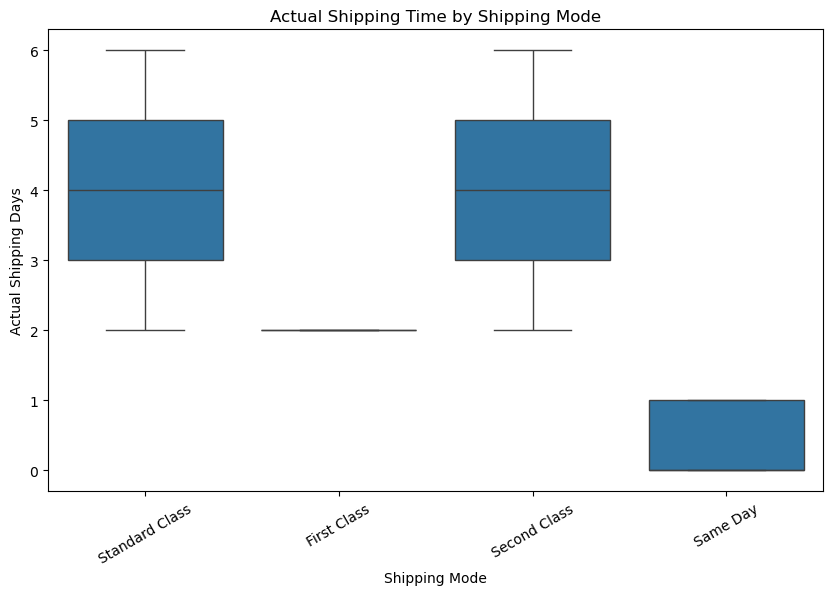

In [48]:
# Actual vs Scheduled Shipping Time

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Shipping_Mode",
    y="Days_for_shipping_(real)"
)

plt.title("Actual Shipping Time by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Actual Shipping Days")

plt.xticks(rotation=30)

plt.show()

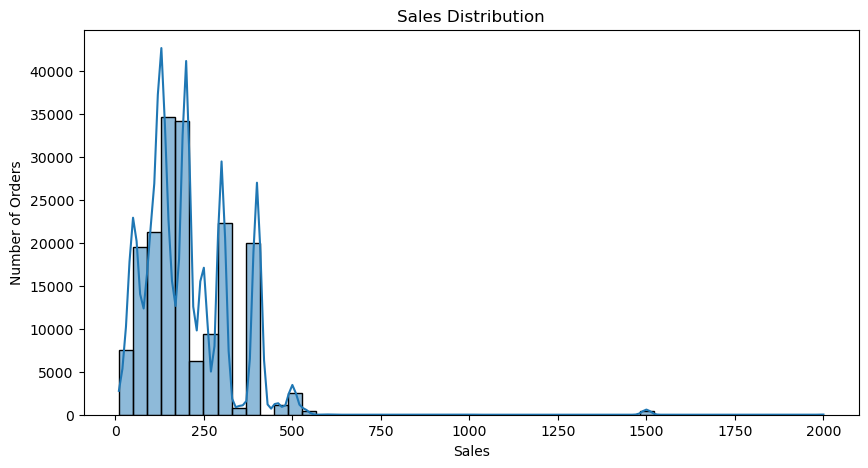

In [49]:
# Sales and Profit Analysis
# Sales distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Sales",
    bins=50,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")

plt.show()

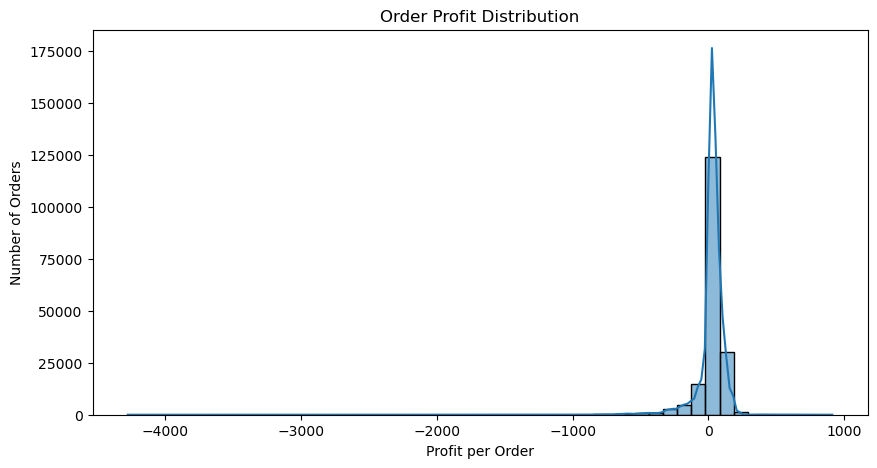

In [50]:
# Profit distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Order_Profit_Per_Order",
    bins=50,
    kde=True
)

plt.title("Order Profit Distribution")
plt.xlabel("Profit per Order")
plt.ylabel("Number of Orders")

plt.show()

In [51]:
# Logistics KPI Summary

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Late Delivery Rate (%)",
        "On-Time Delivery Rate (%)",
        "Average Actual Shipping Days",
        "Average Scheduled Shipping Days",
        "Average Shipping Delay",
        "Average Sales",
        "Average Profit per Order"
    ],
    
    "Value": [
        len(df),
        df["Late_delivery_risk"].mean() * 100,
        (1 - df["Late_delivery_risk"].mean()) * 100,
        df["Days_for_shipping_(real)"].mean(),
        df["Days_for_shipment_(scheduled)"].mean(),
        df["Shipping_Delay"].mean(),
        df["Sales"].mean(),
        df["Order_Profit_Per_Order"].mean()
    ]
})

kpi_summary["Value"] = kpi_summary["Value"].round(2)

kpi_summary

,KPI,Value
0,Total Orders,180519.00
1,Late Delivery Rate (%),54.83
2,On-Time Delivery Rate (%),45.17
3,Average Actual Shipping Days,3.50
4,Average Scheduled Shipping Days,2.93
5,Average Shipping Delay,0.57
6,Average Sales,203.77
7,Average Profit per Order,21.97


**Feature Engineering**

In [52]:
# Create a Delivery Performance Category

df["Delivery_Performance"] = np.where(
    df["Shipping_Delay"] > 0,
    "Delayed",
    "On_Time_or_Early"
)

df["Delivery_Performance"].value_counts()

Delivery_Performance
Delayed             103400
On_Time_or_Early     77119
Name: count, dtype: int64

In [53]:
# Create Shipping Efficiency
df["Shipping_Efficiency"] = (
    df["Days_for_shipment_(scheduled)"] /
    df["Days_for_shipping_(real)"]
)

df["Shipping_Efficiency"].describe()

count    175439.000000
mean          0.909575
std           0.510299
min           0.000000
25%           0.500000
50%           0.800000
75%           1.000000
max           2.000000
Name: Shipping_Efficiency, dtype: float64

In [54]:
# Create Profit Margin
df["Profit_Margin"] = (
    df["Order_Profit_Per_Order"] /
    df["Sales"]
) * 100

df["Profit_Margin"].describe()

count    180519.000000
mean         10.832612
std          42.059372
min        -274.999998
25%           6.224000
50%          24.251212
75%          33.601431
max          50.044288
Name: Profit_Margin, dtype: float64

In [55]:
# Check Infinite Values
print("Infinite values:", np.isinf(df["Profit_Margin"]).sum())

Infinite values: 0


In [56]:
df["Profit_Margin"] = df["Profit_Margin"].replace(
    [np.inf, -np.inf],
    np.nan
)

In [57]:
df["Profit_Margin"] = df["Profit_Margin"].fillna(
    df["Profit_Margin"].median()
)

In [58]:
# Select Important Features
features = [
    "Days_for_shipment_(scheduled)",
    "Order_Item_Quantity",
    "Sales",
    "Order_Profit_Per_Order",
    "Shipping_Delay",
    "Shipping_Efficiency",
    "Profit_Margin"
]

df[features].head()

,Days_for_shipment_(scheduled),Order_Item_Quantity,Sales,Order_Profit_Per_Order,Shipping_Delay,Shipping_Efficiency,Profit_Margin
0,4,1,327.75,91.250000,-1,1.333333,27.841342
1,4,1,327.75,-249.089996,1,0.800000,-75.999999
2,4,1,327.75,-247.779999,0,1.000000,-75.600305
3,4,1,327.75,22.860001,-1,1.333333,6.974829
4,4,1,327.75,134.210007,-2,2.000000,40.948896


In [59]:
# Check Feature Correlations
correlation_matrix = df[features].corr()

correlation_matrix

,Days_for_shipment_(scheduled),Order_Item_Quantity,Sales,Order_Profit_Per_Order,Shipping_Delay,Shipping_Efficiency,Profit_Margin
Days_for_shipment_(scheduled),1.000000,-0.002925,0.006327,-0.000185,-0.360037,0.638080,-0.001653
Order_Item_Quantity,-0.002925,1.000000,0.106442,0.015696,0.001813,-0.001971,0.001374
Sales,0.006327,0.106442,1.000000,0.131816,-0.003695,0.006406,-0.001777
Order_Profit_Per_Order,-0.000185,0.015696,0.131816,1.000000,-0.005385,0.005380,0.826243
Shipping_Delay,-0.360037,0.001813,-0.003695,-0.005385,1.000000,-0.882626,-0.003441
Shipping_Efficiency,0.638080,-0.001971,0.006406,0.005380,-0.882626,1.000000,0.003348
Profit_Margin,-0.001653,0.001374,-0.001777,0.826243,-0.003441,0.003348,1.000000


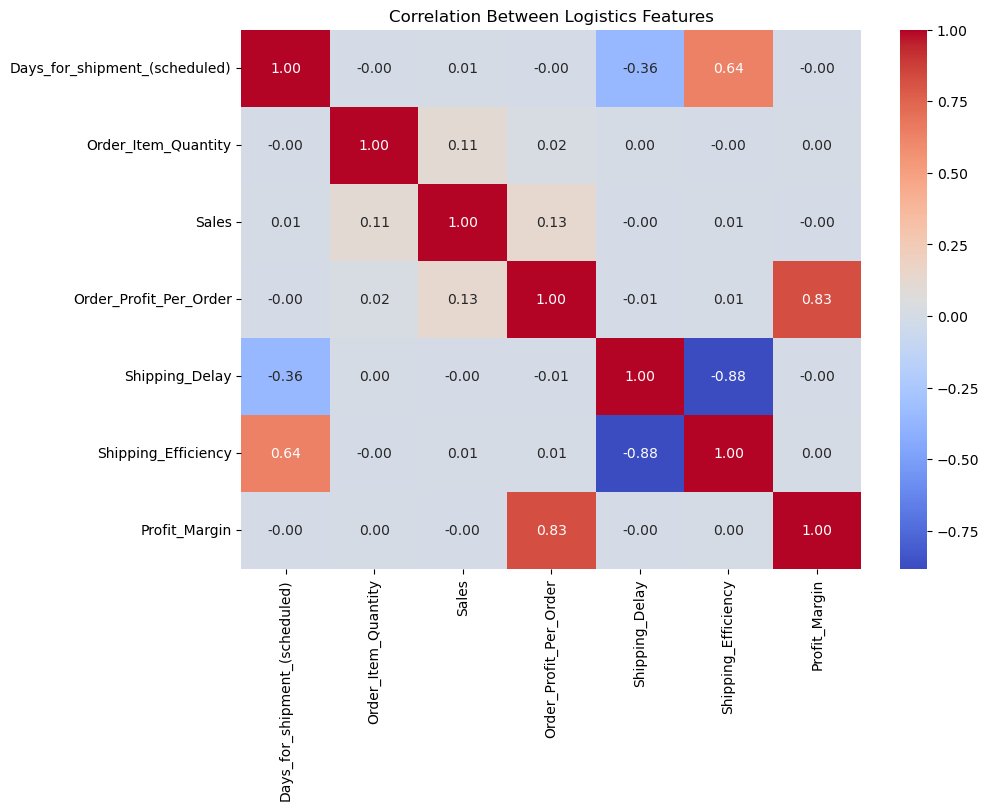

In [60]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Logistics Features")

plt.show()

In [61]:
# Statistical Analysis
late_orders = df[
    df["Late_delivery_risk"] == 1
]["Shipping_Delay"]

on_time_orders = df[
    df["Late_delivery_risk"] == 0
]["Shipping_Delay"]

print("Late orders average delay:",
      late_orders.mean())

print("On-time orders average delay:",
      on_time_orders.mean())

Late orders average delay: 1.6181840225506936
On-time orders average delay: -0.7115842142699468


In [62]:
# T-Test
t_stat, p_value = stats.ttest_ind(
    late_orders,
    on_time_orders,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 519.2561202136196
P-value: 0.0


In [63]:
# Preparing Dataset for Classification
classification_features = [
    "Days_for_shipment_(scheduled)",
    "Order_Item_Quantity",
    "Sales",
    "Order_Profit_Per_Order",
    "Shipping_Delay",
    "Shipping_Efficiency",
    "Profit_Margin"
]

X_classification = df[classification_features].copy()

y_classification = df["Late_delivery_risk"].copy()

print("X shape:", X_classification.shape)
print("y shape:", y_classification.shape)

X shape: (180519, 7)
y shape: (180519,)


In [64]:
# Final Classification Features
classification_features = [
    "Days_for_shipment_(scheduled)",
    "Order_Item_Quantity",
    "Sales",
    "Order_Profit_Per_Order",
    "Profit_Margin"
]

X_classification = df[classification_features].copy()

y_classification = df["Late_delivery_risk"].copy()

print("Features:", classification_features)
print("X shape:", X_classification.shape)
print("y shape:", y_classification.shape)

Features: ['Days_for_shipment_(scheduled)', 'Order_Item_Quantity', 'Sales', 'Order_Profit_Per_Order', 'Profit_Margin']
X shape: (180519, 5)
y shape: (180519,)


In [65]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 144415
Testing samples: 36104


In [66]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed")

Feature scaling completed


**Logistic Regression**

In [67]:
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [68]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic)
logistic_recall = recall_score(y_test, y_pred_logistic)
logistic_f1 = f1_score(y_test, y_pred_logistic)

print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1 Score : {logistic_f1:.4f}")

Accuracy : 0.6919
Precision: 0.7968
Recall   : 0.5880
F1 Score : 0.6767


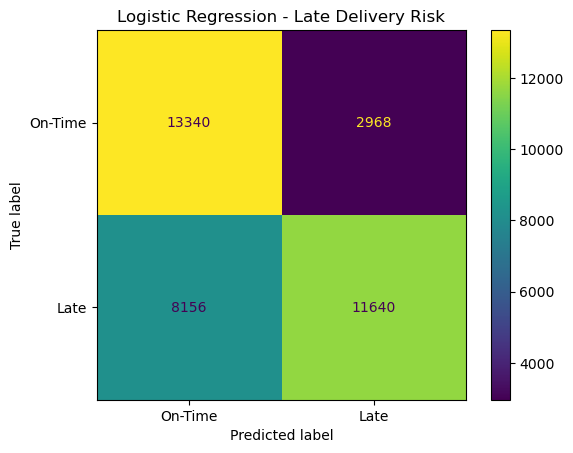

In [69]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["On-Time", "Late"]
)

disp.plot()

plt.title("Logistic Regression - Late Delivery Risk")
plt.show()

In [70]:
# Random Forest Classification
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(X_train, y_train)

y_pred_rf = rf_classifier.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [71]:
# Evaluate Random Forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Accuracy : 0.6335
Precision: 0.6760
Recall   : 0.6369
F1 Score : 0.6558


In [72]:
# Compare Classification Models
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ]
})

classification_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6919,0.7968,0.5880,0.6767
1,Random Forest,0.6335,0.6760,0.6369,0.6558


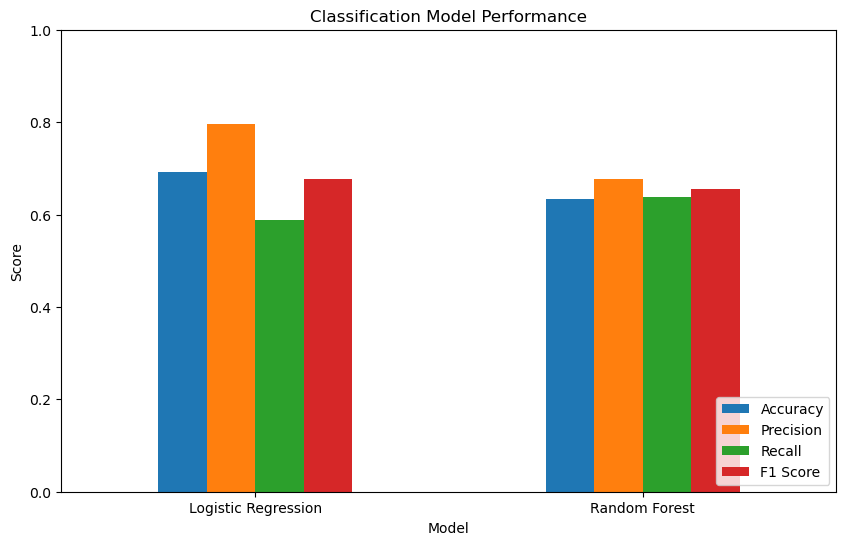

In [73]:
classification_results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Classification Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

In [74]:
# Identify Important Factors
feature_importance = pd.DataFrame({
    "Feature": classification_features,
    "Importance": rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,Profit_Margin,0.320313
3,Order_Profit_Per_Order,0.317402
0,Days_for_shipment_(scheduled),0.299391
2,Sales,0.052233
1,Order_Item_Quantity,0.010661


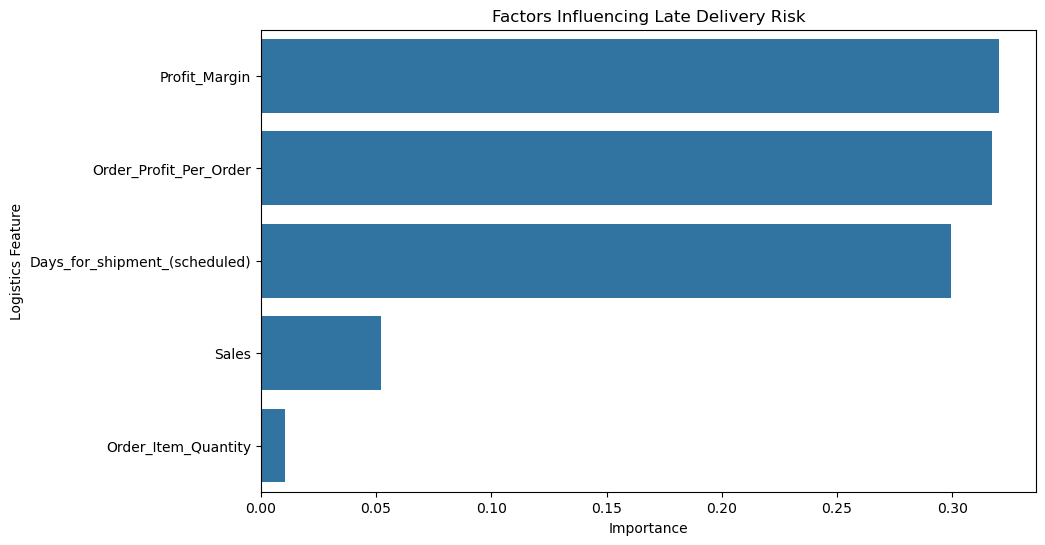

In [75]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Factors Influencing Late Delivery Risk")
plt.xlabel("Importance")
plt.ylabel("Logistics Feature")

plt.show()

In [76]:
# Select the Better Classification Model
best_classification_model = classification_results.loc[
    classification_results["F1 Score"].idxmax()
]

print("Best Classification Model:")
print(best_classification_model)

Best Classification Model:
Model        Logistic Regression
Accuracy                 0.69189
Precision               0.796824
Recall                  0.587998
F1 Score                0.676666
Name: 0, dtype: object


## Business Interpretation
## Late Delivery Prediction — Business Interpretation

The classification models were developed to identify orders that are at risk of
late delivery. Logistic Regression provides a baseline model, while Random Forest
captures more complex relationships between logistics variables.

The model performance was compared using accuracy, precision, recall, and F1-score.
The model with the strongest F1-score is selected as the preferred classification
model.

Feature importance analysis helps identify the logistics factors that contribute
most to late-delivery prediction. These insights can support proactive shipment
planning, resource allocation, and operational decision-making.

**Prepare Regression Dataset**
- Predict the actual number of shipping days for an order.

In [77]:
regression_features = [
    "Days_for_shipment_(scheduled)",
    "Order_Item_Quantity",
    "Sales",
    "Order_Profit_Per_Order",
    "Profit_Margin"
]

X_regression = df[regression_features].copy()
y_regression = df["Days_for_shipping_(real)"].copy()

print("Features:", regression_features)
print("X shape:", X_regression.shape)
print("y shape:", y_regression.shape)

Features: ['Days_for_shipment_(scheduled)', 'Order_Item_Quantity', 'Sales', 'Order_Profit_Per_Order', 'Profit_Margin']
X shape: (180519, 5)
y shape: (180519,)


In [78]:
# Train/Test Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression,
    y_regression,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train_reg.shape[0])
print("Testing samples:", X_test_reg.shape[0])

Training samples: 144415
Testing samples: 36104


In [79]:
# Linear Regression
linear_model = LinearRegression()

linear_model.fit(
    X_train_reg,
    y_train_reg
)

y_pred_linear = linear_model.predict(X_test_reg)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [80]:
# Evaluate Linear Regression
linear_mae = mean_absolute_error(
    y_test_reg,
    y_pred_linear
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_linear
    )
)

linear_r2 = r2_score(
    y_test_reg,
    y_pred_linear
)

print(f"MAE : {linear_mae:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R²  : {linear_r2:.4f}")

MAE : 1.1296
RMSE: 1.3875
R²  : 0.2697


In [84]:
# Random Forest Regression
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(
    X_train_reg,
    y_train_reg
)

y_pred_rf_reg = rf_regressor.predict(
    X_test_reg
)

print("Random Forest Regression model trained successfully.")

Random Forest Regression model trained successfully.


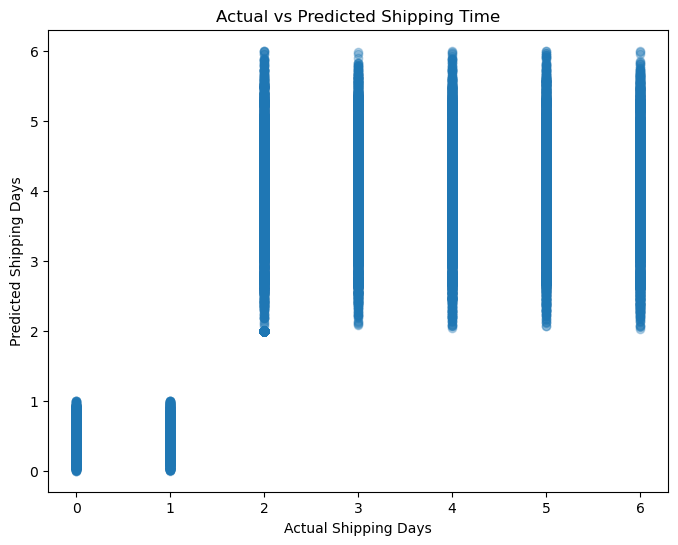

In [87]:
# Actual vs Predicted Shipping Time
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_reg,
    y_pred_rf_reg,
    alpha=0.3
)

plt.xlabel("Actual Shipping Days")
plt.ylabel("Predicted Shipping Days")

plt.title("Actual vs Predicted Shipping Time")

plt.show()

In [88]:
# Regression Feature Importance
regression_importance = pd.DataFrame({
    "Feature": regression_features,
    "Importance": rf_regressor.feature_importances_
})

regression_importance = regression_importance.sort_values(
    "Importance",
    ascending=False
)

regression_importance

,Feature,Importance
0,Days_for_shipment_(scheduled),0.552804
4,Profit_Margin,0.201438
3,Order_Profit_Per_Order,0.180287
2,Sales,0.042483
1,Order_Item_Quantity,0.022987


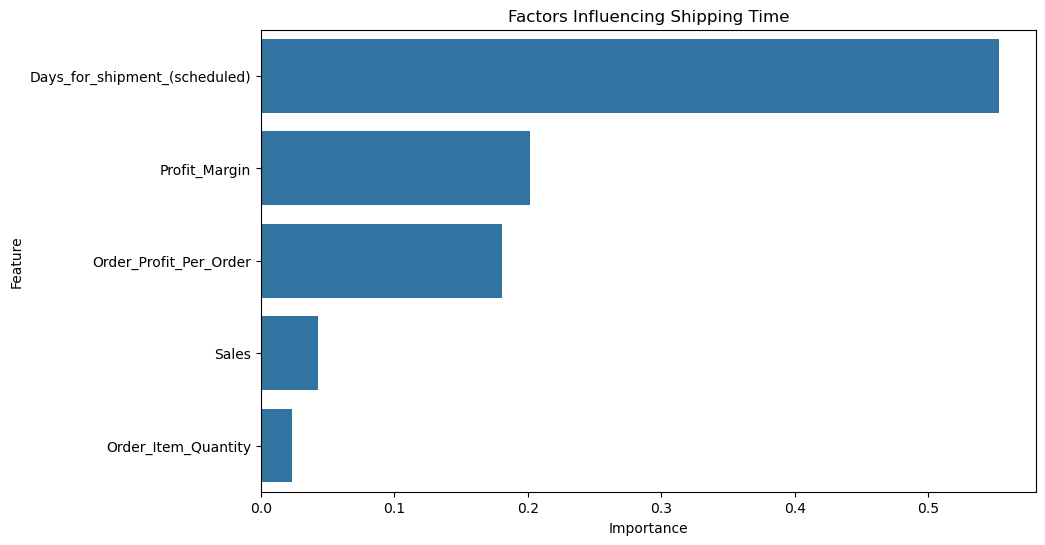

In [89]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=regression_importance,
    x="Importance",
    y="Feature"
)

plt.title("Factors Influencing Shipping Time")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Business Interpretation
#### Shipping Time Prediction — Business Interpretation

Regression models were developed to estimate the actual shipping time of orders.
Linear Regression was used as a baseline model, while Random Forest Regression
was used to capture more complex relationships.

The models were evaluated using MAE, RMSE, and R² score. Lower MAE and RMSE
indicate smaller prediction errors, while a higher R² score indicates better
explanatory and predictive performance.

The regression results can help logistics managers estimate shipping time in
advance and improve shipment scheduling, capacity planning, and resource
allocation.

**Logistics Order Segmentation**

In [90]:
# Create Clustering Dataset
clustering_features = [
    "Sales",
    "Order_Profit_Per_Order",
    "Order_Item_Quantity",
    "Days_for_shipment_(scheduled)",
    "Days_for_shipping_(real)",
    "Shipping_Delay"
]

X_cluster = df[clustering_features].copy()

X_cluster.head()

,Sales,Order_Profit_Per_Order,Order_Item_Quantity,Days_for_shipment_(scheduled),Days_for_shipping_(real),Shipping_Delay
0,327.75,91.250000,1,4,3,-1
1,327.75,-249.089996,1,4,5,1
2,327.75,-247.779999,1,4,4,0
3,327.75,22.860001,1,4,3,-1
4,327.75,134.210007,1,4,2,-2


In [91]:
# Scale the Clustering Data
cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print("Clustering data standardized successfully.")

Clustering data standardized successfully.


In [92]:
# Find the Optimal Number of Clusters
inertia = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster_scaled)
    
    inertia.append(kmeans.inertia_)

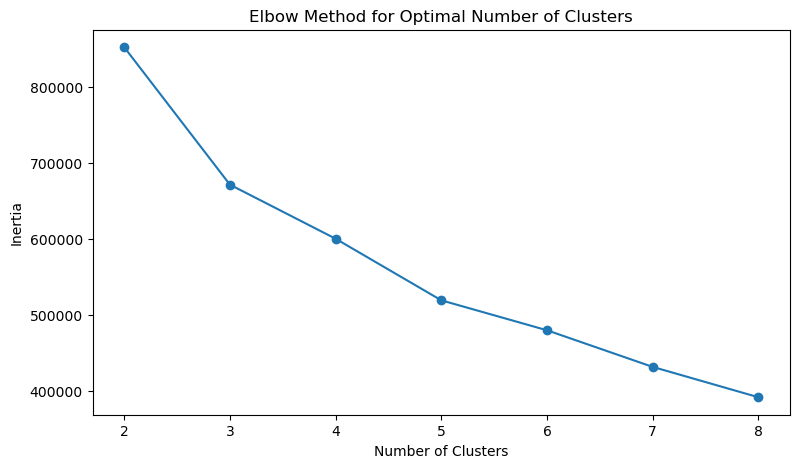

In [93]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [94]:
# Create the Clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Order_Cluster"] = kmeans.fit_predict(
    X_cluster_scaled
)

df["Order_Cluster"].value_counts().sort_index()

Order_Cluster
0    53227
1    45329
2    52098
3    29865
Name: count, dtype: int64

In [95]:
# Analyze Cluster Characteristics
cluster_profile = (
    df.groupby("Order_Cluster")
    .agg(
        Orders=("Order_Cluster", "count"),
        Average_Sales=("Sales", "mean"),
        Average_Profit=("Order_Profit_Per_Order", "mean"),
        Average_Quantity=("Order_Item_Quantity", "mean"),
        Average_Scheduled_Days=("Days_for_shipment_(scheduled)", "mean"),
        Average_Actual_Days=("Days_for_shipping_(real)", "mean"),
        Average_Shipping_Delay=("Shipping_Delay", "mean"),
        Late_Delivery_Rate=("Late_delivery_risk", "mean")
    )
)

cluster_profile["Late_Delivery_Rate"] *= 100

cluster_profile.round(2)

,Orders,Average_Sales,Average_Profit,Average_Quantity,Average_Scheduled_Days,Average_Actual_Days,Average_Shipping_Delay,Late_Delivery_Rate
Order_Cluster,,,,,,,,
0,53227,187.02,18.04,1.64,3.32,5.38,2.06,95.92
1,45329,188.97,18.79,1.77,1.03,1.79,0.76,72.79
2,52098,185.83,19.79,1.54,4.00,2.95,-1.05,0.00
3,29865,287.39,37.64,4.55,3.26,3.68,0.41,49.99


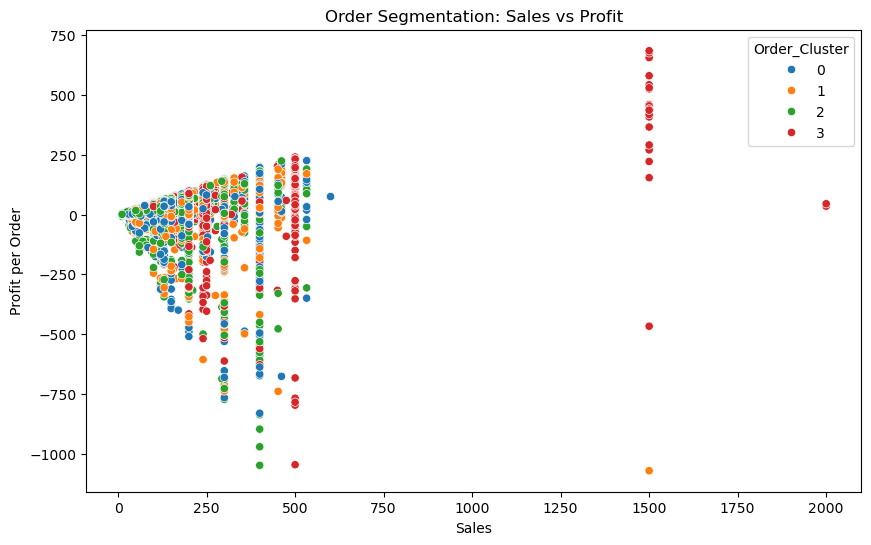

In [97]:
# Visualize Cluster Characteristics
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(min(10000, len(df)), random_state=42),
    x="Sales",
    y="Order_Profit_Per_Order",
    hue="Order_Cluster",
    palette="tab10"
)

plt.title("Order Segmentation: Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit per Order")

plt.show()

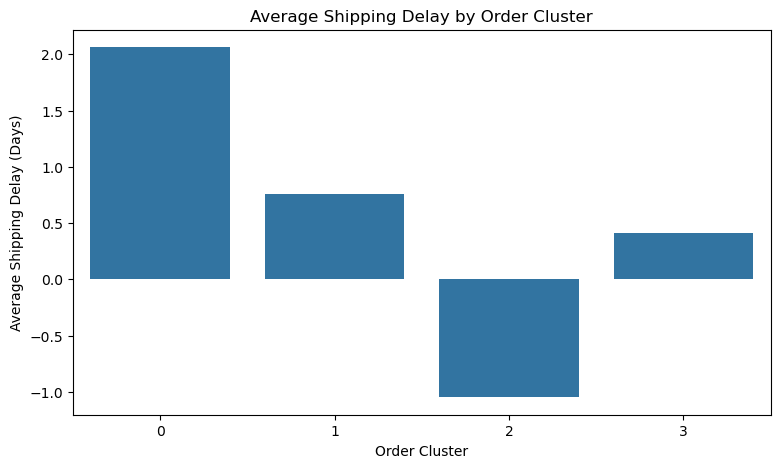

In [98]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=cluster_profile.reset_index(),
    x="Order_Cluster",
    y="Average_Shipping_Delay"
)

plt.title("Average Shipping Delay by Order Cluster")
plt.xlabel("Order Cluster")
plt.ylabel("Average Shipping Delay (Days)")

plt.show()

In [99]:
# Identify High-Risk Cluster
highest_risk_cluster = cluster_profile[
    "Late_Delivery_Rate"
].idxmax()

highest_risk_rate = cluster_profile.loc[
    highest_risk_cluster,
    "Late_Delivery_Rate"
]

print("Highest-risk cluster:", highest_risk_cluster)
print(f"Late delivery rate: {highest_risk_rate:.2f}%")

Highest-risk cluster: 0
Late delivery rate: 95.92%


## Business Interpretation
#### Logistics Segmentation — Business Interpretation

K-Means clustering was used to segment orders according to their sales,
profitability, order quantity, scheduled shipping time, actual shipping time,
and shipping delay.

The resulting clusters represent different operational patterns within the
supply chain. Cluster profiling helps identify groups with higher shipping
delays or higher late-delivery risk.

The high-risk cluster can be prioritized for operational improvements such as
better shipment planning, additional logistics resources, improved scheduling,
or closer monitoring.

This segmentation can support more targeted resource allocation instead of
applying the same logistics strategy to every order.

## Logistics Resource Allocation

In [100]:
# Calculate Risk Score
df["Logistics_Risk_Score"] = (
    df["Late_delivery_risk"] * 2
    + df["Shipping_Delay"].clip(lower=0)
    + df["Days_for_shipment_(scheduled)"] * 0.5
)

df["Logistics_Risk_Score"].describe()

count    180519.000000
mean          3.488564
std           1.791050
min           0.000000
25%           2.000000
50%           3.500000
75%           5.000000
max           7.000000
Name: Logistics_Risk_Score, dtype: float64

In [101]:
# Identify High-Risk Orders
high_risk_orders = df[
    df["Logistics_Risk_Score"] >=
    df["Logistics_Risk_Score"].quantile(0.75)
].copy()

print("Total high-risk orders:", len(high_risk_orders))

Total high-risk orders: 61537


In [102]:
# High-Risk Orders by Region
high_risk_region = (
    high_risk_orders
    .groupby("Order_Region")
    .size()
    .sort_values(ascending=False)
)

high_risk_region.head(10)

Order_Region
Central America    9790
Western Europe     9326
South America      5046
Oceania            3552
Northern Europe    3354
Southeast Asia     3283
Southern Europe    3016
West of USA        2725
Caribbean          2716
South Asia         2677
dtype: int64

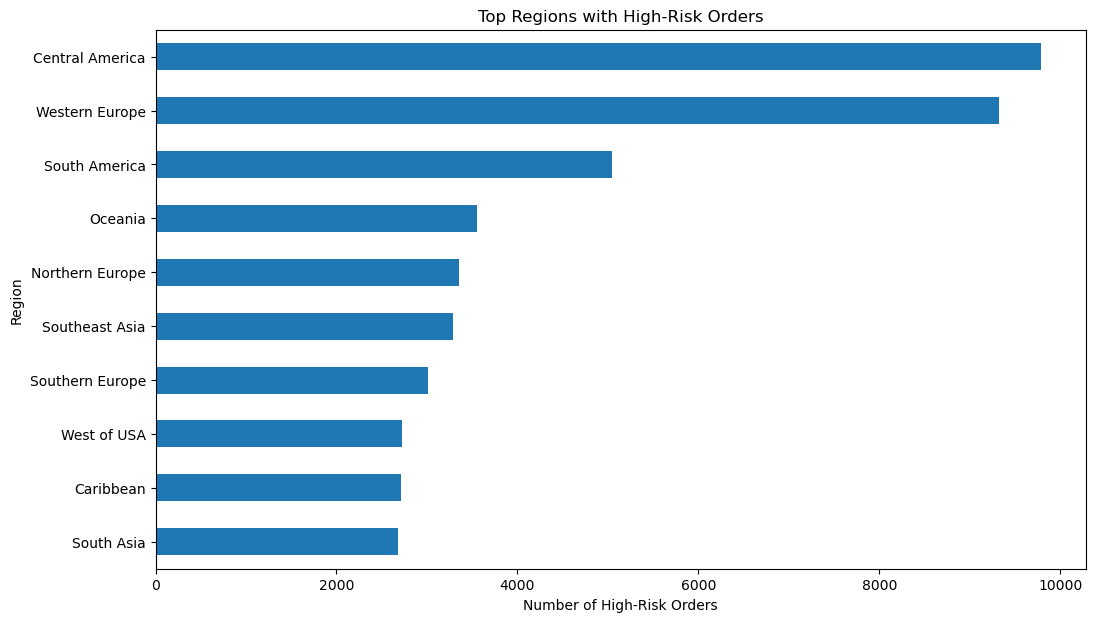

In [103]:
plt.figure(figsize=(12, 7))

high_risk_region.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top Regions with High-Risk Orders")
plt.xlabel("Number of High-Risk Orders")
plt.ylabel("Region")

plt.show()

In [104]:
# High-Risk Orders by Shipping Mode
high_risk_shipping = (
    high_risk_orders
    .groupby("Shipping_Mode")
    .agg(
        High_Risk_Orders=("Shipping_Mode", "count"),
        Average_Risk_Score=("Logistics_Risk_Score", "mean"),
        Average_Delay=("Shipping_Delay", "mean")
    )
    .sort_values(
        "High_Risk_Orders",
        ascending=False
    )
)

high_risk_shipping.round(2)

,High_Risk_Orders,Average_Risk_Score,Average_Delay
Shipping_Mode,,,
Standard Class,41023,5.51,1.51
Second Class,20514,5.98,3.01


In [105]:
# Create Resource Priority
df["Resource_Priority"] = pd.cut(
    df["Logistics_Risk_Score"],
    bins=[
        -np.inf,
        df["Logistics_Risk_Score"].quantile(0.50),
        df["Logistics_Risk_Score"].quantile(0.75),
        np.inf
    ],
    labels=[
        "Normal",
        "High",
        "Critical"
    ]
)

df["Resource_Priority"].value_counts()

Resource_Priority
Normal      110995
High         35263
Critical     34261
Name: count, dtype: int64

In [107]:
# Analyze Resource Priority
resource_priority = (
    df.groupby("Resource_Priority", observed=True)
    .agg(
        Orders=("Resource_Priority", "count"),
        Average_Risk_Score=("Logistics_Risk_Score", "mean"),
        Average_Delay=("Shipping_Delay", "mean"),
        Late_Delivery_Rate=("Late_delivery_risk", "mean")
    )
)

resource_priority["Late_Delivery_Rate"] *= 100

resource_priority.round(2)

,Orders,Average_Risk_Score,Average_Delay,Late_Delivery_Rate
Resource_Priority,,,,
Normal,110995,2.24,-0.28,27.90
High,35263,4.77,1.26,95.71
Critical,34261,6.20,2.59,100.00


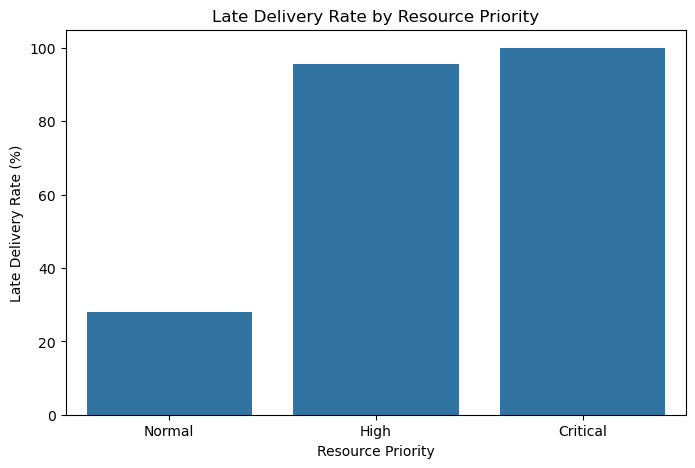

In [108]:
# Visualize Resource Priority
plt.figure(figsize=(8, 5))

sns.barplot(
    data=resource_priority.reset_index(),
    x="Resource_Priority",
    y="Late_Delivery_Rate",
    order=["Normal", "High", "Critical"]
)

plt.title("Late Delivery Rate by Resource Priority")
plt.xlabel("Resource Priority")
plt.ylabel("Late Delivery Rate (%)")

plt.show()

## Resource Allocation Recommendation
#### Logistics Optimization — Business Interpretation

A risk-based resource allocation strategy was developed using the logistics
risk score. Orders were categorized into Normal, High, and Critical priority
groups.

Critical orders represent shipments requiring the highest operational
attention. These orders can be prioritized for additional logistics resources,
closer monitoring, improved scheduling, or faster shipping options.

High-priority orders should receive proactive monitoring, while normal orders
can continue through standard logistics processes.

This approach helps logistics managers allocate limited resources according
to operational risk rather than treating every shipment equally.

In [109]:
# Final Project Summary Table
final_summary = pd.DataFrame({
    "Analysis": [
        "Late Delivery Prediction",
        "Shipping Time Prediction",
        "Order Segmentation",
        "Resource Allocation"
    ],
    "Purpose": [
        "Identify orders at risk of late delivery",
        "Estimate actual shipping time",
        "Group similar logistics orders",
        "Prioritize high-risk shipments"
    ],
    "Business_Use": [
        "Proactive shipment planning",
        "Better scheduling and capacity planning",
        "Targeted logistics strategies",
        "Risk-based resource allocation"
    ]
})

final_summary

,Analysis,Purpose,Business_Use
0,Late Delivery Prediction,Identify orders at risk of late delivery,Proactive shipment planning
1,Shipping Time Prediction,Estimate actual shipping time,Better scheduling and capacity planning
2,Order Segmentation,Group similar logistics orders,Targeted logistics strategies
3,Resource Allocation,Prioritize high-risk shipments,Risk-based resource allocation


In [116]:
# Save the Final Analytical Dataset
import os

output_folder = r"C:\Users\arkat\OneDrive\Desktop\M.tech\b.techprojects\Internship projects\Logistics Data Analyst Intern\TASK-1\Output"

os.makedirs(output_folder, exist_ok=True)

output_path = os.path.join(
    output_folder,
    "DataCo_Final_Analysis_Dataset.csv"
)

df.to_csv(
    output_path,
    index=False
)

print("Final analytical dataset saved successfully.")
print(output_path)

Final analytical dataset saved successfully.
C:\Users\arkat\OneDrive\Desktop\M.tech\b.techprojects\Internship projects\Logistics Data Analyst Intern\TASK-1\Output\DataCo_Final_Analysis_Dataset.csv


In [117]:
# Save KPI Results
kpi_summary.to_csv(
    os.path.join(output_folder, "Logistics_KPI_Summary.csv"),
    index=False
)

print("KPI summary saved successfully.")

KPI summary saved successfully.


In [120]:
# SAVE MODEL RESULTS

# Make sure required libraries are available
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import pandas as pd
import os

# --------------------------------------------
# 1. Classification Results
# --------------------------------------------

classification_results.to_csv(
    os.path.join(
        output_folder,
        "Classification_Model_Results.csv"
    ),
    index=False
)

# --------------------------------------------
# 2. Recalculate Linear Regression Metrics
# --------------------------------------------

linear_mae = mean_absolute_error(
    y_test_reg,
    y_pred_linear
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_linear
    )
)

linear_r2 = r2_score(
    y_test_reg,
    y_pred_linear
)

# --------------------------------------------
# 3. Recalculate Random Forest Regression Metrics
# --------------------------------------------

rf_mae = mean_absolute_error(
    y_test_reg,
    y_pred_rf_reg
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_rf_reg
    )
)

rf_r2 = r2_score(
    y_test_reg,
    y_pred_rf_reg
)

# --------------------------------------------
# 4. Create Regression Results Table
# --------------------------------------------

regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

# --------------------------------------------
# 5. Save Regression Results
# --------------------------------------------

regression_results.to_csv(
    os.path.join(
        output_folder,
        "Regression_Model_Results.csv"
    ),
    index=False
)

print("Classification and regression results saved successfully.")

print("\nRegression Results:")
display(regression_results.round(4))

Classification and regression results saved successfully.

Regression Results:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.1296,1.3875,0.2697
1,Random Forest Regression,1.0807,1.4069,0.2491


In [121]:
# Save Cluster Profile
cluster_profile.to_csv(
    os.path.join(
        output_folder,
        "Logistics_Cluster_Profile.csv"
    )
)

print("Cluster profile saved successfully.")

Cluster profile saved successfully.


## Overall Project Results

In [122]:
# Classification Results
print("=== LATE DELIVERY CLASSIFICATION RESULTS ===")

display(
    classification_results.round(4)
)

=== LATE DELIVERY CLASSIFICATION RESULTS ===


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6919,0.7968,0.5880,0.6767
1,Random Forest,0.6335,0.6760,0.6369,0.6558


In [123]:
# Regression Results
print("=== SHIPPING TIME REGRESSION RESULTS ===")

display(
    regression_results.round(4)
)

=== SHIPPING TIME REGRESSION RESULTS ===


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.1296,1.3875,0.2697
1,Random Forest Regression,1.0807,1.4069,0.2491


In [124]:
# Clustering Results
print("=== LOGISTICS CLUSTER PROFILE ===")

display(
    cluster_profile.round(2)
)

=== LOGISTICS CLUSTER PROFILE ===


,Orders,Average_Sales,Average_Profit,Average_Quantity,Average_Scheduled_Days,Average_Actual_Days,Average_Shipping_Delay,Late_Delivery_Rate
Order_Cluster,,,,,,,,
0,53227,187.02,18.04,1.64,3.32,5.38,2.06,95.92
1,45329,188.97,18.79,1.77,1.03,1.79,0.76,72.79
2,52098,185.83,19.79,1.54,4.00,2.95,-1.05,0.00
3,29865,287.39,37.64,4.55,3.26,3.68,0.41,49.99


**Identify Best Models**

In [125]:
best_classification = classification_results.loc[
    classification_results["F1 Score"].idxmax()
]

best_regression = regression_results.loc[
    regression_results["R2 Score"].idxmax()
]

print("Best Classification Model:")
print(best_classification)

print("\nBest Regression Model:")
print(best_regression)

Best Classification Model:
Model        Logistic Regression
Accuracy                 0.69189
Precision               0.796824
Recall                  0.587998
F1 Score                0.676666
Name: 0, dtype: object

Best Regression Model:
Model       Linear Regression
MAE                  1.129613
RMSE                 1.387504
R2 Score             0.269661
Name: 0, dtype: object


**Identify Key Logistics Findings**

In [126]:
# Highest-risk region
highest_risk_region = region_analysis[
    "Late_Delivery_Rate"
].idxmax()

highest_risk_region_rate = region_analysis.loc[
    highest_risk_region,
    "Late_Delivery_Rate"
]

print("Highest-risk region:", highest_risk_region)
print(
    f"Late delivery rate: "
    f"{highest_risk_region_rate:.2f}%"
)

Highest-risk region: Central Africa
Late delivery rate: 57.96%


In [127]:
# Highest-risk shipping mode
highest_risk_shipping_mode = shipping_delay_mode[
    "Late_Delivery_Rate"
].idxmax()

shipping_mode_rate = shipping_delay_mode.loc[
    highest_risk_shipping_mode,
    "Late_Delivery_Rate"
]

print(
    "Highest-risk shipping mode:",
    highest_risk_shipping_mode
)

print(
    f"Late delivery rate: "
    f"{shipping_mode_rate:.2f}%"
)

Highest-risk shipping mode: First Class
Late delivery rate: 95.32%


In [128]:
# Highest-risk order cluster
print(
    "Highest-risk order cluster:",
    highest_risk_cluster
)

print(
    f"Late delivery rate: "
    f"{highest_risk_rate:.2f}%"
)

Highest-risk order cluster: 0
Late delivery rate: 95.92%


**Create Final KPI Dashboard Table**

In [129]:
final_kpis = pd.DataFrame({
    "KPI": [
        "Total Orders",
        "Late Delivery Rate",
        "On-Time Delivery Rate",
        "Average Actual Shipping Time",
        "Average Scheduled Shipping Time",
        "Average Shipping Delay",
        "Average Sales per Order",
        "Average Profit per Order"
    ],
    
    "Value": [
        len(df),
        df["Late_delivery_risk"].mean() * 100,
        (1 - df["Late_delivery_risk"].mean()) * 100,
        df["Days_for_shipping_(real)"].mean(),
        df["Days_for_shipment_(scheduled)"].mean(),
        df["Shipping_Delay"].mean(),
        df["Sales"].mean(),
        df["Order_Profit_Per_Order"].mean()
    ]
})

final_kpis["Value"] = final_kpis["Value"].round(2)

display(final_kpis)

,KPI,Value
0,Total Orders,180519.00
1,Late Delivery Rate,54.83
2,On-Time Delivery Rate,45.17
3,Average Actual Shipping Time,3.50
4,Average Scheduled Shipping Time,2.93
5,Average Shipping Delay,0.57
6,Average Sales per Order,203.77
7,Average Profit per Order,21.97


In [130]:
final_kpis.to_csv(
    os.path.join(
        output_folder,
        "Final_Logistics_KPI_Summary.csv"
    ),
    index=False
)

print("Final KPI summary saved successfully.")

Final KPI summary saved successfully.


In [131]:
# Generate Final Business Insights
print("========== FINAL BUSINESS INSIGHTS ==========\n")

print(
    f"1. The dataset contains {len(df):,} orders."
)

print(
    f"2. The overall late delivery rate is "
    f"{df['Late_delivery_risk'].mean() * 100:.2f}%."
)

print(
    f"3. The average actual shipping time is "
    f"{df['Days_for_shipping_(real)'].mean():.2f} days."
)

print(
    f"4. The average shipping delay is "
    f"{df['Shipping_Delay'].mean():.2f} days."
)

print(
    f"5. {highest_risk_region} has the highest "
    f"late delivery rate among regions."
)

print(
    f"6. {highest_risk_shipping_mode} has the highest "
    f"late delivery rate among shipping modes."
)

print(
    f"7. Cluster {highest_risk_cluster} represents the "
    f"highest-risk order segment."
)

print(
    f"8. The best classification model is "
    f"{best_classification['Model']}."
)

print(
    f"9. The best regression model is "
    f"{best_regression['Model']}."
)

print(
    "10. Risk-based resource allocation can help "
    "prioritize high-risk shipments."
)

========== FINAL BUSINESS INSIGHTS ==========

1. The dataset contains 180,519 orders.
2. The overall late delivery rate is 54.83%.
3. The average actual shipping time is 3.50 days.
4. The average shipping delay is 0.57 days.
5. Central Africa has the highest late delivery rate among regions.
6. First Class has the highest late delivery rate among shipping modes.
7. Cluster 0 represents the highest-risk order segment.
8. The best classification model is Logistic Regression.
9. The best regression model is Linear Regression.
10. Risk-based resource allocation can help prioritize high-risk shipments.


## Final Project Conclusion

# Overall Conclusion

The DataCo Supply Chain dataset was analyzed to understand logistics performance,
identify factors associated with late deliveries, predict shipping outcomes,
segment orders, and support risk-based resource allocation.

The analysis began with data cleaning and exploratory analysis, followed by
logistics KPI evaluation. Classification models were developed to identify
orders at risk of late delivery, while regression models were used to estimate
shipping time. K-Means clustering was applied to identify groups of orders with
similar logistics and business characteristics.

Finally, a logistics risk score was developed to prioritize high-risk shipments
for additional operational attention and resource allocation.

The results provide a data-driven framework that can help logistics managers
improve shipment planning, monitor delivery risks, allocate resources more
effectively, and make informed supply-chain decisions.

# Final Notebook Structure

### Project Workflow Completed

1. Project Definition
2. Dataset Understanding
3. Data Cleaning and Preprocessing
4. Exploratory Data Analysis
5. Logistics KPI Analysis
6. Feature Engineering
7. Statistical Analysis
8. Late Delivery Risk Classification
9. Shipping Time Regression
10. Logistics Order Clustering
11. Risk-Based Resource Allocation
12. Model Evaluation
13. Business Insights
14. Final Conclusion